**3.1 Load Data and Import Libraries**

**1. Import Libraries: Begin by importing the necessary libraries for data manipulation,
visualization, and machine learning. Common libraries include pandas, numpy, matplotlib,
seaborn, and scikit-learn, among others.**

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score

import joblib


**2. Load Data: Load the dataset into a pandas DataFrame. Ensure the data is loaded correctly
and is in a format suitable for preprocessing.**

In [104]:
url = "https://docs.google.com/spreadsheets/d/1XDti944oeXNAFk1ktMu3raMQnAdkketW/export?format=csv&gid=358820224"
df = pd.read_csv(url)

# Check data types
print("\nData Types:")
print(df.dtypes)


print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
print()
print('First 5 rows:')
df.head()



Data Types:
FileName        str
Date            str
SegFile         str
b           float64
e           float64
LBE         float64
LB          float64
AC          float64
FM          float64
UC          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
DL          float64
DS          float64
DP          float64
DR          float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
A           float64
B           float64
C           float64
D           float64
E           float64
AD          float64
DE          float64
LD          float64
FS          float64
SUSP        float64
CLASS       float64
NSP         float64
dtype: object
Shape: (2130, 40)  (2,130 rows × 40 columns)

First 5 rows:


,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1/12/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,3/5/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,3/5/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,3/5/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


**3.2 Data Preprocessing, Exploratory Data Analysis (EDA), and Train-Test Split**

**1. Data Preprocessing: Clean the data by handling missing values, encoding categorical
variables, and scaling numerical features. Apply transformations as needed based on the
type of data.**

Extra Columns That Need To Be Dropeed

In [105]:

cols_to_drop = ['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'DR',
                'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS']

df = df.drop(columns=cols_to_drop)

Total Null Values

In [106]:
print("Total NullValues in the dataset:", df.isnull().sum().sum())

print("\nNull values per column\n")
print(df.isnull().sum())

Total NullValues in the dataset: 76

Null values per column

LB          4
AC          4
FM          3
UC          3
ASTV        3
MSTV        3
ALTV        3
MLTV        3
DL          2
DS          2
DP          2
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
NSP         4
dtype: int64


Fetching Rows That Contain Only Null Values

In [107]:
# fetching all the rows where everything is null
print(df[df.isnull().all(axis=1)])

      LB  AC  FM  UC  ASTV  MSTV  ALTV  MLTV  DL  DS  ...  Min  Max  Nmax  \
0    NaN NaN NaN NaN   NaN   NaN   NaN   NaN NaN NaN  ...  NaN  NaN   NaN   
2127 NaN NaN NaN NaN   NaN   NaN   NaN   NaN NaN NaN  ...  NaN  NaN   NaN   

      Nzeros  Mode  Mean  Median  Variance  Tendency  NSP  
0        NaN   NaN   NaN     NaN       NaN       NaN  NaN  
2127     NaN   NaN   NaN     NaN       NaN       NaN  NaN  

[2 rows x 22 columns]


Dropping Rows That Contain Only Null Values

In [108]:
df = df.dropna(how='all').reset_index(drop=True)

Dropping Rows Where NSP(target variable) Is Null

In [109]:
df = df.dropna(subset=['NSP']).reset_index(drop=True)

Checking For Duplicates

In [110]:
total_duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicate_rows}")
print(f"\n{'='*50}")
print("All Duplicate Rows:")
print(f"{'='*50}")
print(df[df.duplicated()])



Total duplicate rows: 14

All Duplicate Rows:
         LB   AC    FM   UC  ASTV  MSTV  ALTV  MLTV   DL   DS  ...    Min  \
68    140.0  5.0   0.0  3.0  34.0   1.2   0.0  10.3  0.0  0.0  ...  119.0   
234   123.0  0.0   0.0  0.0  49.0   0.8   7.0  13.8  0.0  0.0  ...   63.0   
306   145.0  0.0  13.0  0.0  77.0   0.2  45.0   5.8  0.0  0.0  ...  129.0   
319   150.0  0.0  10.0  0.0  79.0   0.2  84.0   2.8  0.0  0.0  ...  147.0   
324   135.0  0.0   0.0  0.0  62.0   0.5  71.0   6.9  0.0  0.0  ...   71.0   
333   144.0  0.0  15.0  0.0  76.0   0.4  61.0  10.6  0.0  0.0  ...   71.0   
787   123.0  3.0   4.0  0.0  52.0   0.8   2.0  15.4  0.0  0.0  ...   50.0   
791   123.0  2.0   3.0  0.0  50.0   0.9   4.0  14.8  0.0  0.0  ...   58.0   
798   146.0  0.0   0.0  4.0  65.0   0.4  39.0   7.0  0.0  0.0  ...  137.0   
849   138.0  2.0   0.0  4.0  41.0   0.8   8.0  10.3  0.0  0.0  ...  105.0   
1113  122.0  0.0   0.0  0.0  19.0   1.9   0.0  15.1  0.0  0.0  ...  103.0   
1114  122.0  0.0   0.0  0.0  1

Dropping Duplicate Rows

In [111]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)  # should be (2112, 22)
print("Duplicates remaining:", df.duplicated().sum())  # should be 0

Shape after dropping duplicates: (2112, 22)
Duplicates remaining: 0


Dataset Shape After A Clean-Up Job

In [112]:
print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
print()

Shape: (2112, 22)  (2,112 rows × 22 columns)



Separating Target and Features Columns

In [113]:
# Separate features (X) and target (y)
X = df.drop(columns=['NSP'])
y = df['NSP']


In [114]:
# Verify
print("Features shape:", X.shape)   
print("Target shape:", y.shape)     
print("\nTarget values:", y.unique())  
print("\nTarget distribution:\n", y.value_counts().sort_index())
print("Any nulls left:", df.isnull().sum().sum())  # 0


Features shape: (2112, 21)
Target shape: (2112,)

Target values: [2. 1. 3.]

Target distribution:
 NSP
1.0    1646
2.0     292
3.0     174
Name: count, dtype: int64
Any nulls left: 0


There is no need for encoding as all the columns that will be used are numerical columns



In [115]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
DL          float64
DS          float64
DP          float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
NSP         float64
dtype: object

**2. Exploratory Data Analysis (EDA): Perform an initial analysis of the data to understand
distributions, identify relationships, and spot outliers. This may involve generating summary
statistics and visualizations. Handle the outliers and multicollinearity.**

**Statistics Summary**

In [116]:
df.describe()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,...,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,133.296875,2.733902,7.267992,3.678504,46.978693,1.335559,9.759943,8.169176,1.580492,0.003314,...,93.539299,164.105587,4.078598,0.325758,137.448390,134.592803,138.083333,18.916193,0.318655,1.303030
std,9.833066,3.567741,37.244378,2.844685,17.167716,0.884232,18.270136,5.633034,2.504219,0.057489,...,29.546379,17.947492,2.951603,0.707903,16.403636,15.610971,14.479658,29.042726,0.611180,0.613314
min,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,0.000000,0.000000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,0.000000,4.600000,0.000000,0.000000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,0.000000,7.400000,0.000000,0.000000,...,93.000000,162.000000,4.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,11.000000,10.800000,3.000000,0.000000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,91.000000,50.700000,16.000000,1.000000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


**Distribution of Each Feature**

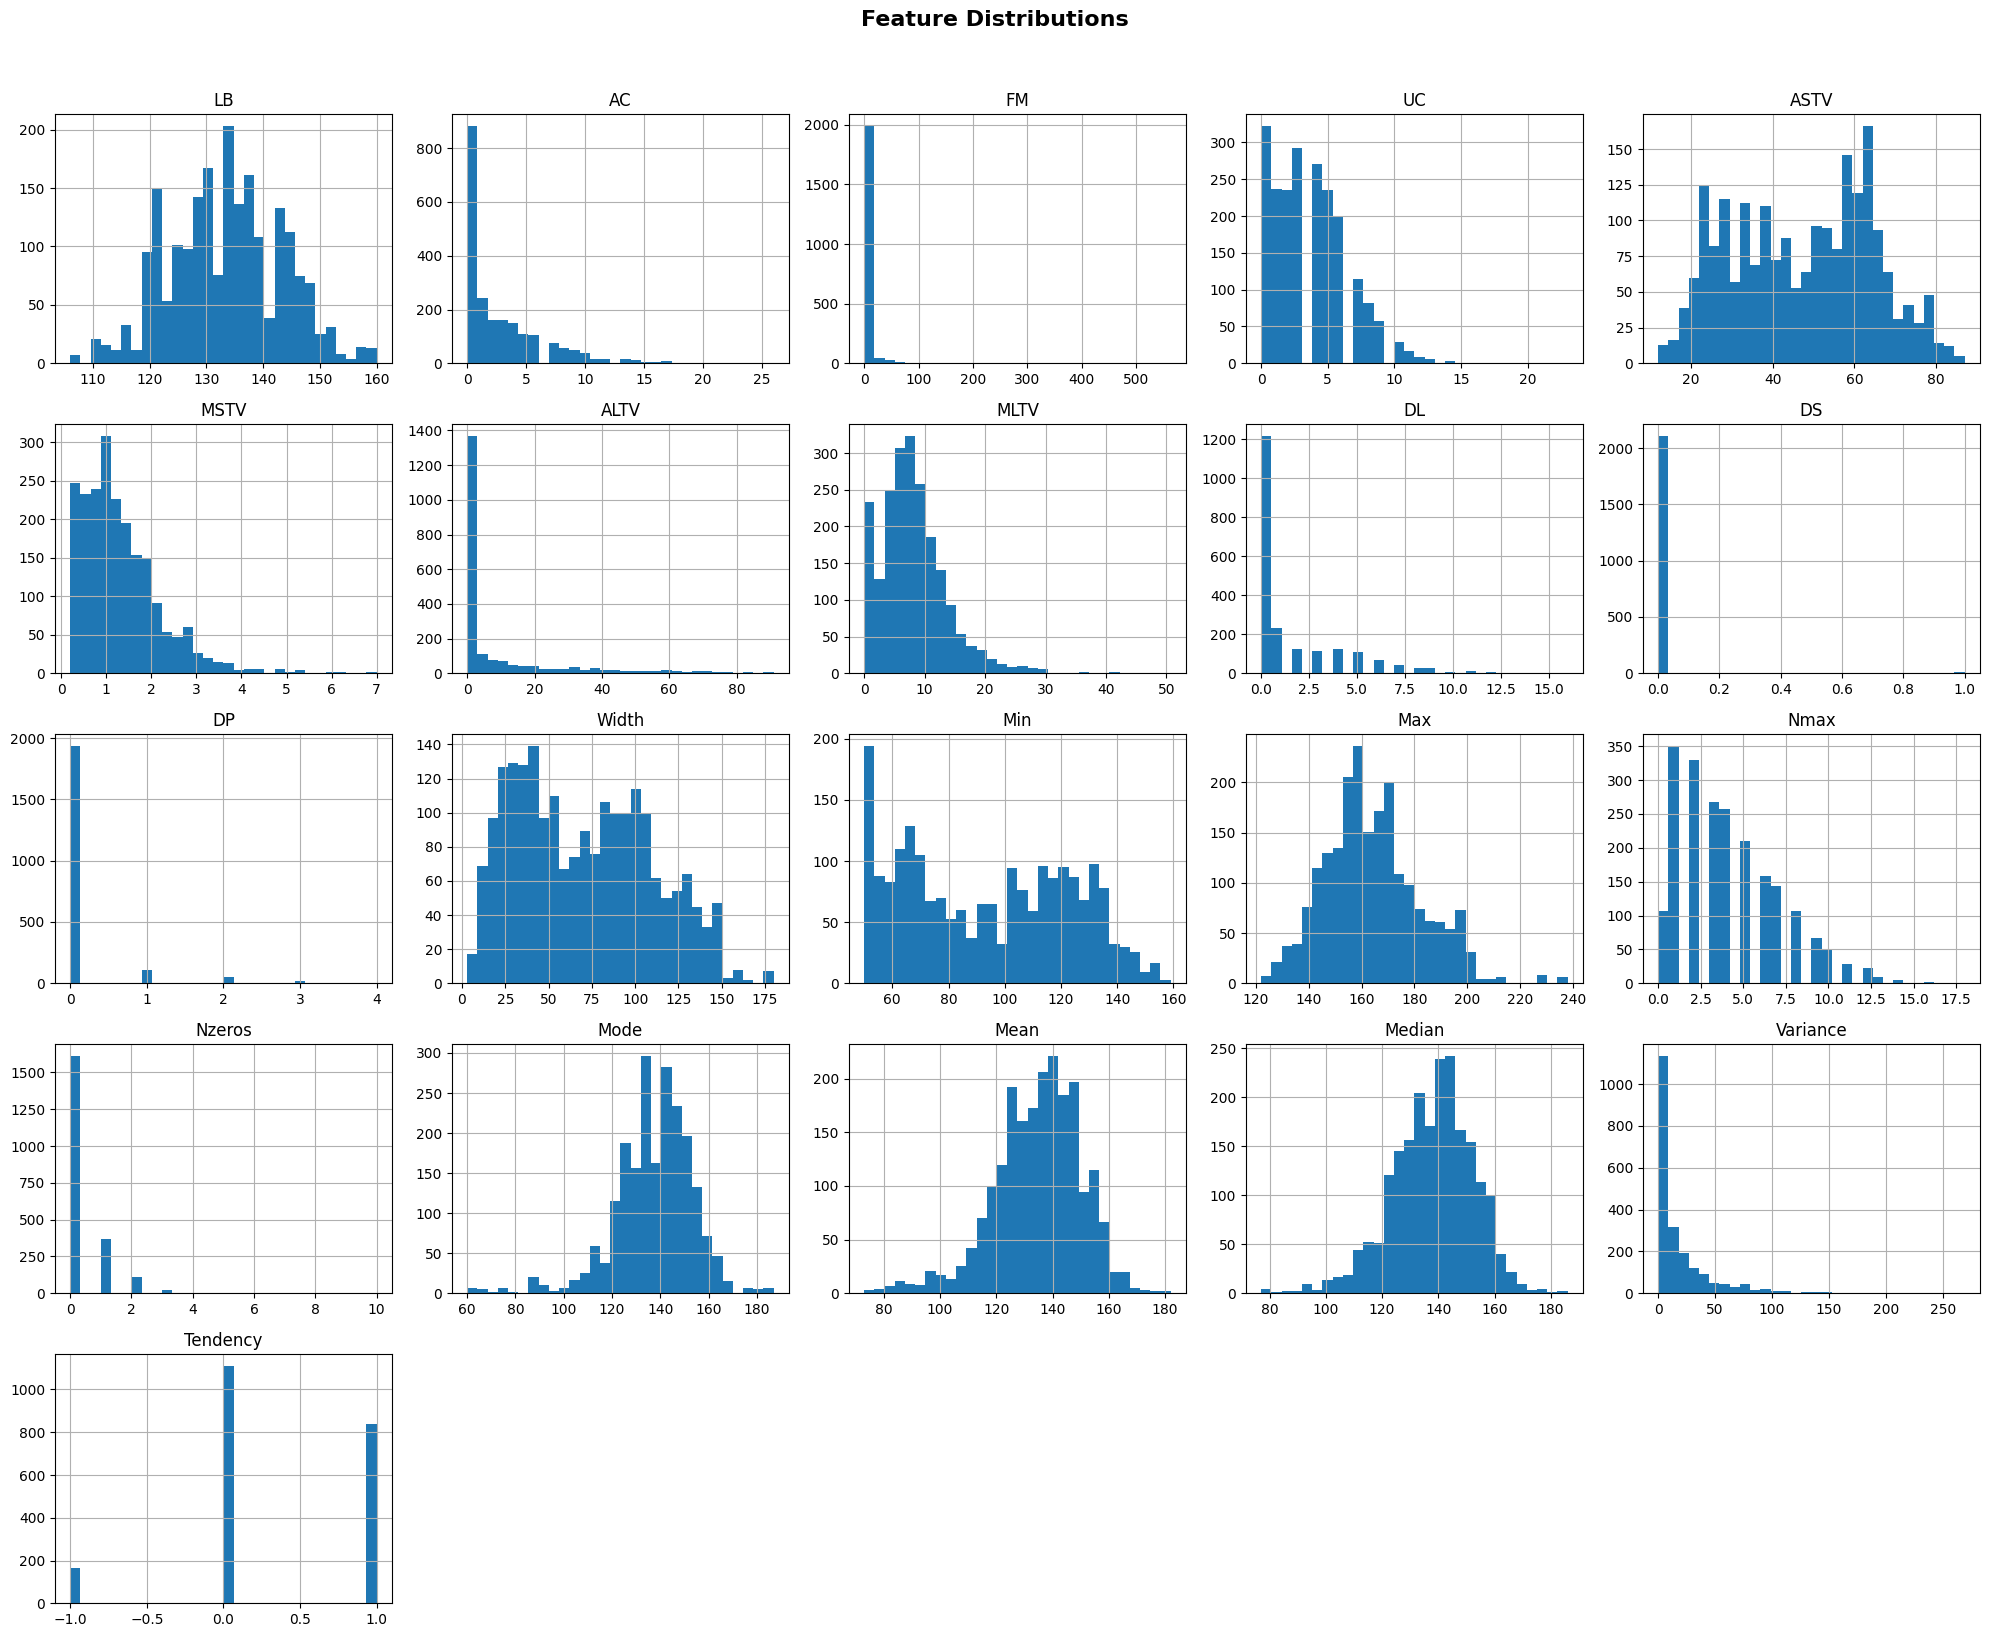

In [117]:
X.hist(figsize=(20, 16), bins=30)
plt.suptitle("Feature Distributions", fontsize=16,fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Outlier Detection**

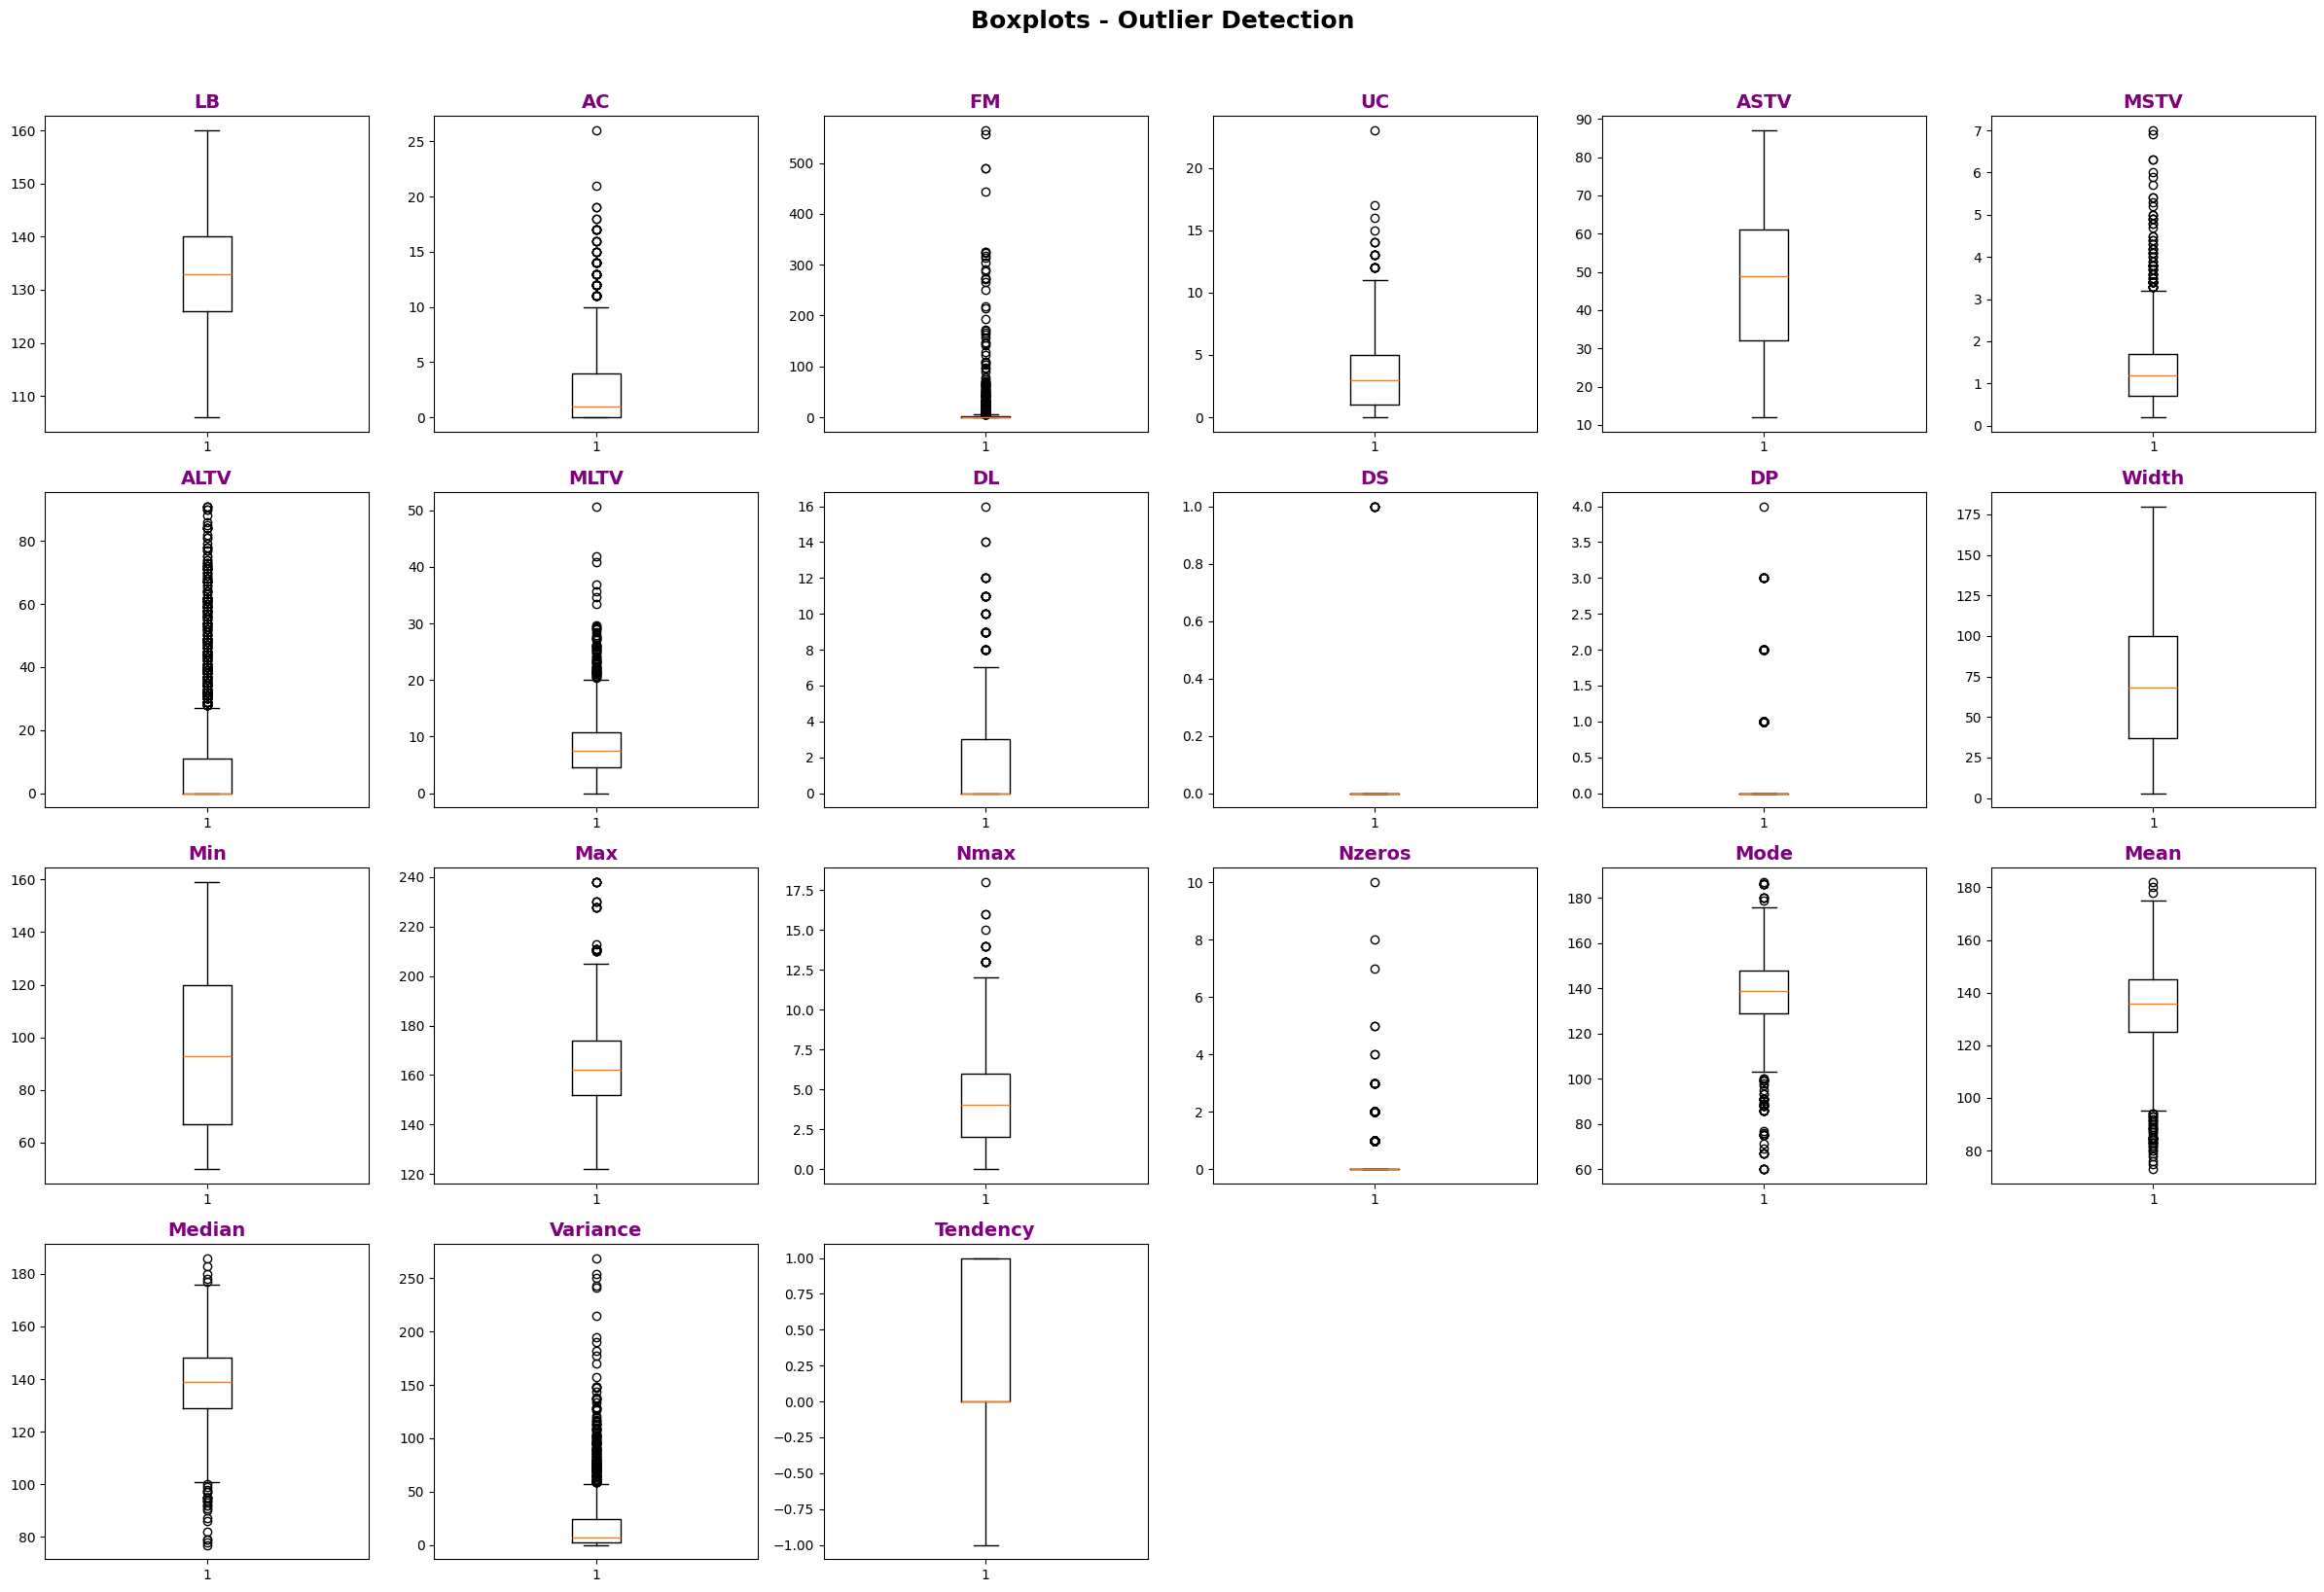

In [118]:
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col].dropna())
    axes[i].set_title(col, fontsize=14,fontweight='bold',color='purple')

for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)


plt.suptitle("Boxplots - Outlier Detection", fontsize=18,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

**Outlier Count Per Feature**

In [119]:
def count_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    return ((col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)).sum()

outliers = pd.DataFrame({
    'Outlier Count': X.apply(count_outliers),
    'Outlier %': (X.apply(count_outliers) / len(X) * 100).round(2)
}).sort_values('Outlier Count', ascending=False)

print(outliers)

          Outlier Count  Outlier %
Nzeros              502      23.77
FM                  307      14.54
ALTV                304      14.39
Variance            184       8.71
DP                  178       8.43
AC                   83       3.93
DL                   81       3.84
Mode                 73       3.46
MLTV                 71       3.36
MSTV                 70       3.31
Mean                 45       2.13
Median               28       1.33
Max                  24       1.14
UC                   22       1.04
Nmax                 19       0.90
DS                    7       0.33
LB                    0       0.00
Min                   0       0.00
Width                 0       0.00
ASTV                  0       0.00
Tendency              0       0.00


**Class Distribution Analysis**

NSP
1.0    1646
2.0     292
3.0     174
Name: count, dtype: int64


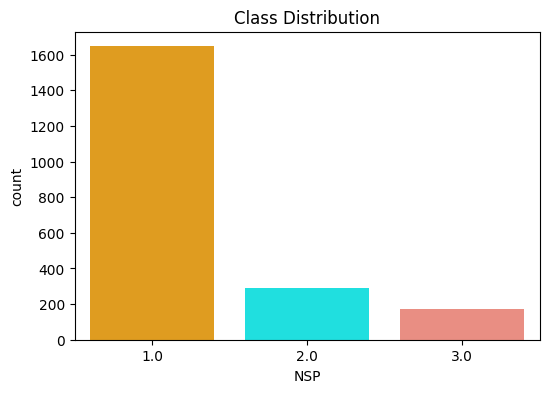

As can be seen, the dataset is imbalanced with class 1 having the most samples, followed by class 2 and then class 3.


In [120]:
#Data is imbalanced

print(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y, data=df, hue=y, legend=False, palette=['orange','cyan','salmon'])
plt.title('Class Distribution')
plt.show()

print('As can be seen, the dataset is imbalanced with class 1 having the most samples, followed by class 2 and then class 3.')

**Feature vs Target Relationship**

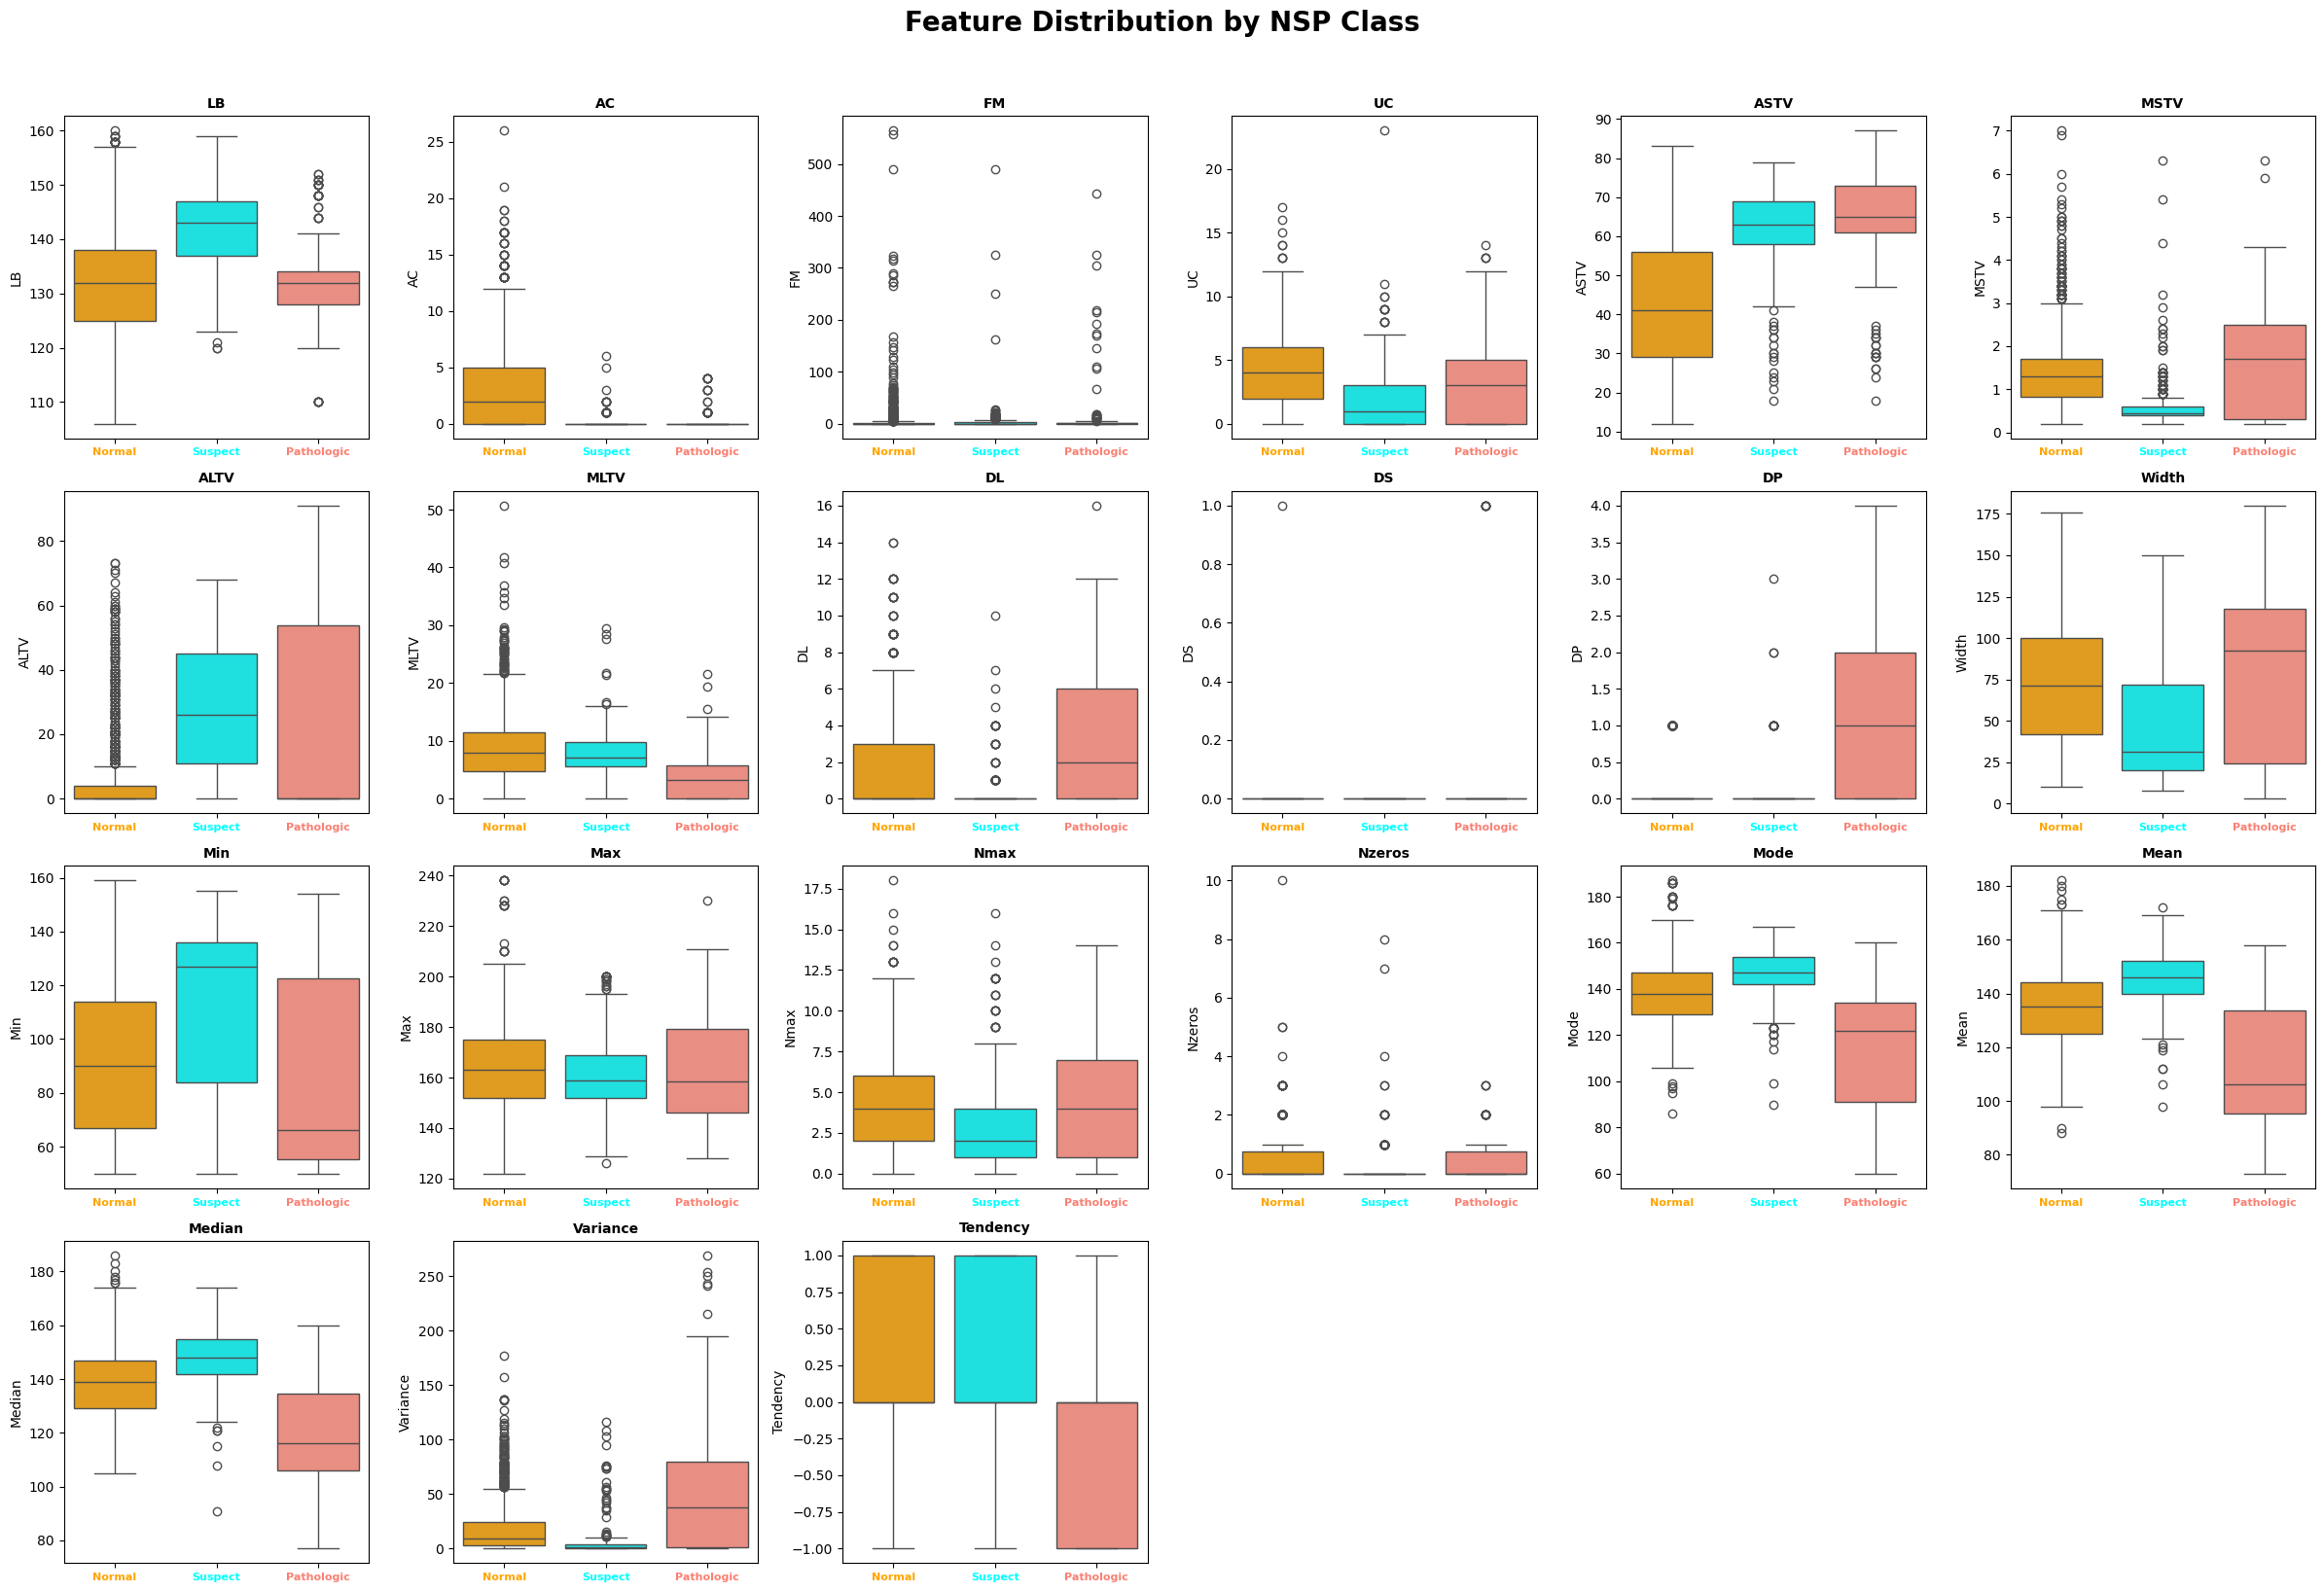

In [121]:
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

palette = {1.0: 'orange', 2.0: 'cyan', 3.0: 'salmon'}
colors = ['orange', 'cyan', 'salmon']
labels = ['Normal', 'Suspect', 'Pathologic']

for i, col in enumerate(X.columns):
    sns.boxplot(data=df, x='NSP', y=col,
                hue='NSP',
                palette=palette,
                legend=False,
                ax=axes[i])

    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

    # Fix: set ticks first then labels
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(labels, fontsize=8, fontweight='bold')

    # Color each x tick label
    for tick, color in zip(axes[i].get_xticklabels(), colors):
        tick.set_color(color)

for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distribution by NSP Class", fontsize=20, fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

**Feature Correlation with NSP Target Heatmap**

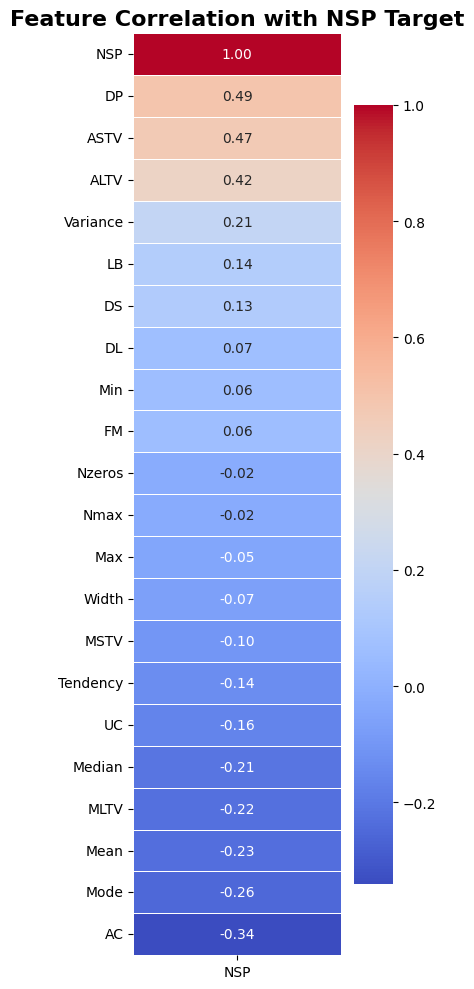

In [122]:
plt.figure(figsize=(4, 10))
sns.heatmap(df[X.columns.tolist() + ['NSP']].corr()[['NSP']].sort_values('NSP', ascending=False),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Correlation with NSP Target', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Heatmap For The Correlation Matrix For Features Columns**

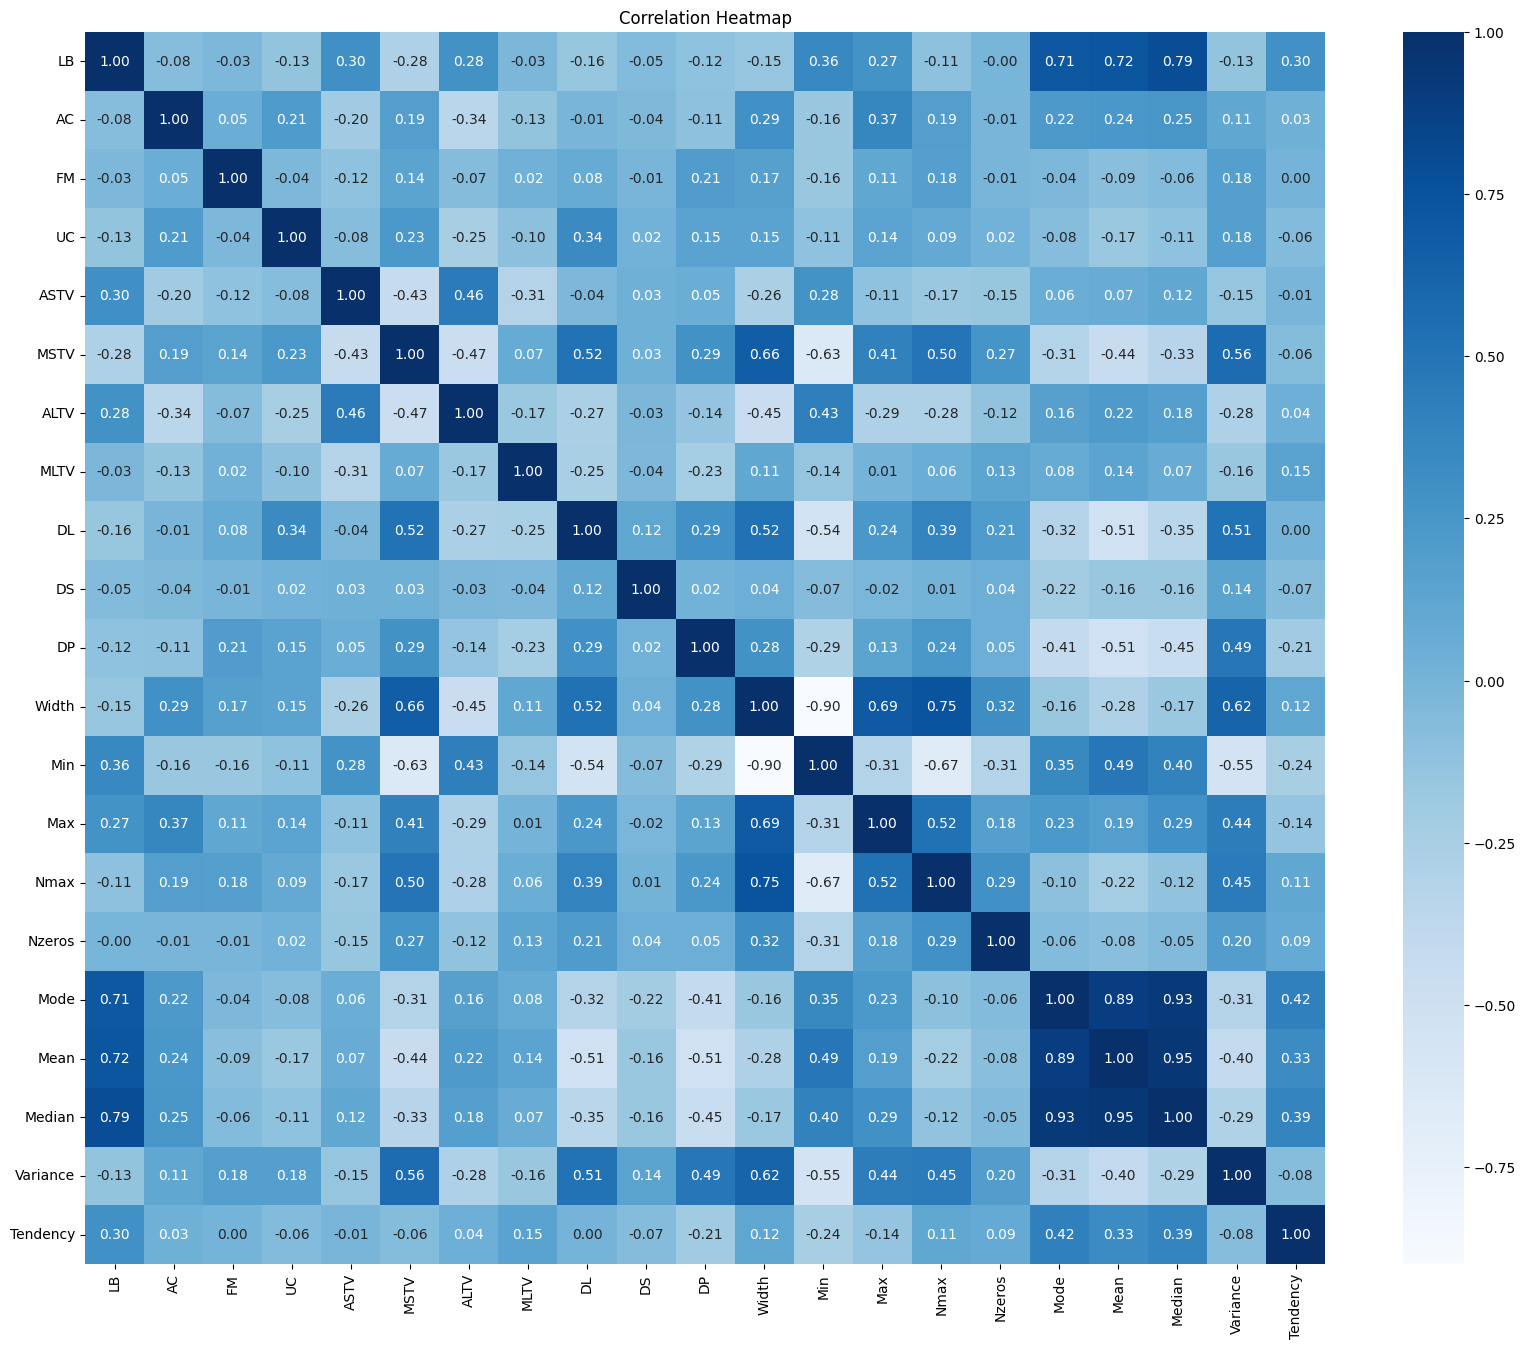

In [123]:
features_corr = X.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(features_corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


**Checking Range Of Values Within Each Column To See Whether Scaling Is Needed Or Not**

In [124]:
range_df = pd.DataFrame({
    'Min': X.min(),
    'Max': X.max(),
    'Range': X.max() - X.min()
}).sort_values('Range', ascending=False)

print(range_df)

            Min    Max  Range
FM          0.0  564.0  564.0
Variance    0.0  269.0  269.0
Width       3.0  180.0  177.0
Mode       60.0  187.0  127.0
Max       122.0  238.0  116.0
Median     77.0  186.0  109.0
Min        50.0  159.0  109.0
Mean       73.0  182.0  109.0
ALTV        0.0   91.0   91.0
ASTV       12.0   87.0   75.0
LB        106.0  160.0   54.0
MLTV        0.0   50.7   50.7
AC          0.0   26.0   26.0
UC          0.0   23.0   23.0
Nmax        0.0   18.0   18.0
DL          0.0   16.0   16.0
Nzeros      0.0   10.0   10.0
MSTV        0.2    7.0    6.8
DP          0.0    4.0    4.0
Tendency   -1.0    1.0    2.0
DS          0.0    1.0    1.0


**3. Train-Test Split: Split the dataset into training and testing sets. The typical ratio for splitting
is 80/20 or 70/30, ensuring that the model can be trained on one portion and evaluated on
another.**

**Train-Test Split: Split data into 80% training and 20% testing.**

In [125]:

## Splitting data in 80% percent for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train.count()


LB          1689
AC          1689
FM          1689
UC          1689
ASTV        1689
MSTV        1689
ALTV        1689
MLTV        1689
DL          1689
DS          1689
DP          1689
Width       1689
Min         1689
Max         1689
Nmax        1689
Nzeros      1689
Mode        1689
Mean        1689
Median      1689
Variance    1689
Tendency    1689
dtype: int64

**Feature Scaling: Apply StandardScaler**

In [126]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved!")


Scaler saved!


**3.3 Model Training**

**1. Model Selection: Choose at least three machine learning models based on the task (e.g.,
classification, regression). Common models include Linear Regression, Logistic Regression,
Decision Tree (or RF), Support Vector Machines, or KNN.**

**2. Train the Base Models: Fit each model using the default parameters (call them base models).
Ensure that all the base models are initialized and trained on the available features and target
variable.**

In [127]:
# Random Forest - no scaling needed for tree-based models
rf_base_model = RandomForestClassifier(random_state=42)
rf_base_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
# SVM - Using X_scaled
svm_base_model = SVC(random_state=42)
svm_base_model.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [129]:
# Logistic Regression - Using X_scaled
lr_base_model = LogisticRegression(max_iter=1000,random_state=42)

lr_base_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**Model Predictions**

In [130]:
# Random Forest Prediction
rf_y_pred = rf_base_model.predict(X_test)

In [131]:
# SVM Prediction
svm_y_pred = svm_base_model.predict(X_test_scaled)


In [132]:
# Logistic Regression Prediction
lr_y_pred = lr_base_model.predict(X_test_scaled)


**Drawing the Confusion Matrices:**

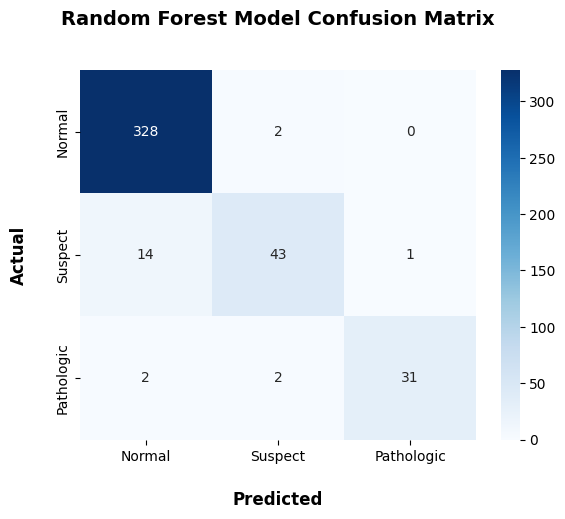

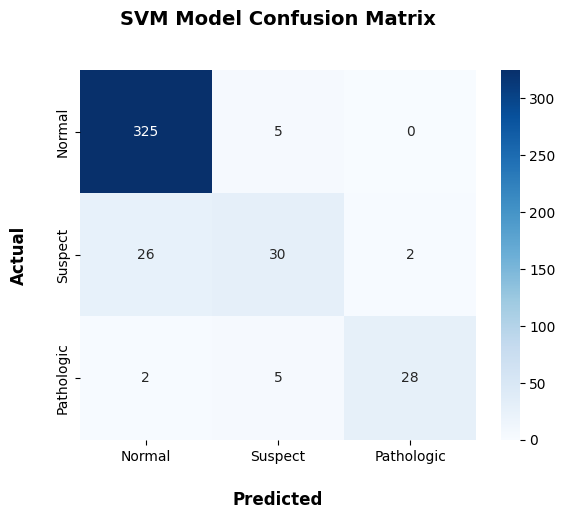

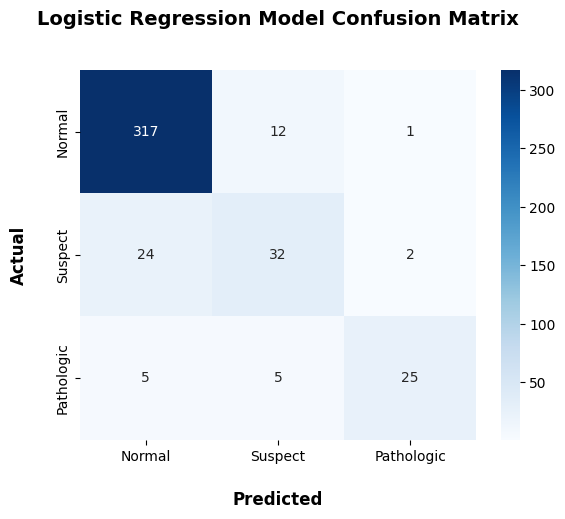

In [133]:

target_names = ['Normal', 'Suspect', 'Pathologic']

for name,pred in zip(['Random Forest','SVM','Logistic Regression'],[rf_y_pred,svm_y_pred,lr_y_pred]):
  sns.heatmap(confusion_matrix(y_test, pred),
              annot=True, fmt="d",
              xticklabels=target_names,
              yticklabels=target_names,
              cmap='Blues')

  plt.xlabel("Predicted",
             fontweight='bold',
             labelpad=20,
             fontsize=12)
  
  plt.ylabel("Actual",
             fontweight='bold',
             labelpad=20,
             fontsize=12)
  
  plt.title(f"{name} Model Confusion Matrix",
            y=1.1,
            fontweight='bold',
            fontsize=14)
  
  plt.show()



**Accuracy,Precision,Recall and F1-Score metrics for all 3 models**

In [134]:

for name, pred in zip(
    ['Random Forest', 'SVM', 'Logistic Regression'],
    [rf_y_pred, svm_y_pred, lr_y_pred]):

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy:          {accuracy_score(y_test, pred):.4f}")
    print(f"Precision (weighted): {precision_score(y_test, pred, average='weighted'):.4f}")
    print(f"Precision (macro):    {precision_score(y_test, pred, average='macro'):.4f}")
    print(f"Recall (weighted):    {recall_score(y_test, pred, average='weighted'):.4f}")
    print(f"Recall (macro):       {recall_score(y_test, pred, average='macro'):.4f}")
    print(f"F1 (weighted):        {f1_score(y_test, pred, average='weighted'):.4f}")
    print(f"F1 (macro):           {f1_score(y_test, pred, average='macro'):.4f}")


  Random Forest
Accuracy:          0.9504
Precision (weighted): 0.9495
Precision (macro):    0.9457
Recall (weighted):    0.9504
Recall (macro):       0.8737
F1 (weighted):        0.9482
F1 (macro):           0.9059

  SVM
Accuracy:          0.9054
Precision (weighted): 0.8983
Precision (macro):    0.8680
Recall (weighted):    0.9054
Recall (macro):       0.7674
F1 (weighted):        0.8977
F1 (macro):           0.8085

  Logistic Regression
Accuracy:          0.8842
Precision (weighted): 0.8782
Precision (macro):    0.8207
Recall (weighted):    0.8842
Recall (macro):       0.7422
F1 (weighted):        0.8794
F1 (macro):           0.7766


**Generating Classification Reports**

In [135]:
# Generate reports
rf_report = classification_report(y_test, rf_y_pred,
             target_names=['Normal', 'Suspect', 'Pathologic'],
             output_dict=True)
svm_report = classification_report(y_test, svm_y_pred,
             target_names=['Normal', 'Suspect', 'Pathologic'],
             output_dict=True)
lr_report = classification_report(y_test, lr_y_pred,
            target_names=['Normal', 'Suspect', 'Pathologic'],
            output_dict=True)

print(classification_report(y_test, rf_y_pred,target_names=['Normal', 'Suspect', 'Pathologic']))


              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       330
     Suspect       0.91      0.74      0.82        58
  Pathologic       0.97      0.89      0.93        35

    accuracy                           0.95       423
   macro avg       0.95      0.87      0.91       423
weighted avg       0.95      0.95      0.95       423



**Saving Classification Reports to json**

In [136]:
# Save to JSON
classification_results= {
    'Random Forest': rf_report,
    'SVM': svm_report,
    'Logistic Regression': lr_report
}

with open('classification_report.json', 'w') as f:
    json.dump(classification_results, f, indent=4)

print("Saved to classification_report.json")

Saved to classification_report.json


**2. Perform additional validation:**


* **K-Fold Cross-Validation**


* Split data into k fold (commonly 5 or 10)

* Train on k-1 and validate on the remaining fold.

* Compute and report the average score across all folds.**

* **Stratified K-Fold Cross-Validation**

* Preserve class distribution in each fold.

* Must be used for imbalanced classification datasets.


In [137]:
# Transform full X for cross validation using already fitted scaler
X_scaled_cv = scaler.transform(X)


In [138]:
# ── K-Fold ──
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_kf  = cross_val_score(rf_base_model,X,y, cv=kf, scoring='f1_macro')
svm_kf = cross_val_score(svm_base_model,X_scaled_cv,y, cv=kf, scoring='f1_macro')
lr_kf  = cross_val_score(lr_base_model,X_scaled_cv,y, cv=kf, scoring='f1_macro')

print("=== K-Fold Cross Validation (5 Folds) ===")
print(f"Random Forest:       {rf_kf.mean():.4f} ± {rf_kf.std():.4f}")
print(f"SVM:                 {svm_kf.mean():.4f} ± {svm_kf.std():.4f}")
print(f"Logistic Regression: {lr_kf.mean():.4f} ± {lr_kf.std():.4f}")



=== K-Fold Cross Validation (5 Folds) ===
Random Forest:       0.8880 ± 0.0295
SVM:                 0.8360 ± 0.0154
Logistic Regression: 0.7938 ± 0.0422


In [139]:
# ── Stratified K-Fold ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_skf  = cross_val_score(rf_base_model,X,y, cv=skf,scoring='f1_macro')
svm_skf = cross_val_score(svm_base_model,X_scaled_cv, y,cv=skf, scoring='f1_macro')
lr_skf  = cross_val_score(lr_base_model,X_scaled_cv, y, cv=skf, scoring='f1_macro')

print("\n=== Stratified K-Fold Cross Validation (5 Folds) ===")
print(f"Random Forest:       {rf_skf.mean():.4f} ± {rf_skf.std():.4f}")
print(f"SVM:                 {svm_skf.mean():.4f} ± {svm_skf.std():.4f}")
print(f"Logistic Regression: {lr_skf.mean():.4f} ± {lr_skf.std():.4f}")


=== Stratified K-Fold Cross Validation (5 Folds) ===
Random Forest:       0.8944 ± 0.0154
SVM:                 0.8266 ± 0.0271
Logistic Regression: 0.7910 ± 0.0207


I performed both K-Fold and Stratified K-Fold Cross-Validation. Our dataset is imbalanced(Normal=77.5%, Pathologic=8.2%). Hence, Stratified K-Fold is the more appropriate validation technique as it preserves class distribution in each fold. Regular K-Fold does not guarantee minority classes are represented in every fold, making its results less reliable for imbalanced datasets.

**3.5 Testing on New Instances**


**After model training and evaluation, test the model on new data points (instances) in a Jupyter notebook environment. This can be done by passing individual or small batches of new data through the model to generate predictions interactively.**

Three hypothetical patient instances were created — one for each fetal state (Normal, Suspect, and Pathologic). Each instance contains realistic CTG feature values within the actual data ranges, designed to represent the typical clinical characteristics of each class. These instances will be passed through the base models and best models to evaluate how well each model detects the correct fetal state.

In [140]:
normal_instance = pd.DataFrame([[
    132,   # LB       - range 106-160  → middle
    3,     # AC       - range 0-26     → some accelerations
    0,     # FM       - range 0-564    → mostly 0
    2,     # UC       - range 0-23     → low contractions
    20,    # ASTV     - range 12-87    → low abnormal
    2.0,   # MSTV     - range 0.2-7    → normal
    8,     # ALTV     - range 0-91     → low abnormal
    12.0,  # MLTV     - range 0-50.7   → good variability
    0,     # DL       - range 0-16     → no decelerations
    0,     # DS       - range 0-1      → no severe
    0,     # DP       - range 0-4      → no prolonged
    100,   # Width    - range 3-180    → wide histogram
    120,   # Min      - range 50-159   → normal min
    160,   # Max      - range 122-238  → normal max
    6,     # Nmax     - range 0-18     → normal peaks
    1,     # Nzeros   - range 0-10     → few zeros
    140,   # Mode     - range 60-187   → normal mode
    138,   # Mean     - range 73-182   → normal mean
    139,   # Median   - range 77-186   → normal median
    10,    # Variance - range 0-269    → low variance
    0      # Tendency - range -1 to 1  → stable
]], columns=X.columns)



suspect_instance = pd.DataFrame([[
    148,   # LB       - range 106-160  → high end
    0,     # AC       - range 0-26     → no accelerations
    0,     # FM       - range 0-564    → no movements
    5,     # UC       - range 0-23     → moderate
    60,    # ASTV     - range 12-87    → high abnormal
    1.0,   # MSTV     - range 0.2-7    → low
    40,    # ALTV     - range 0-91     → high abnormal
    6.0,   # MLTV     - range 0-50.7   → low variability
    3,     # DL       - range 0-16     → some decelerations
    0,     # DS       - range 0-1      → no severe
    0,     # DP       - range 0-4      → no prolonged
    50,    # Width    - range 3-180    → narrow
    95,    # Min      - range 50-159   → low min
    155,   # Max      - range 122-238  → normal max
    3,     # Nmax     - range 0-18     → few peaks
    3,     # Nzeros   - range 0-10     → some zeros
    122,   # Mode     - range 60-187   → low mode
    125,   # Mean     - range 73-182   → low mean
    124,   # Median   - range 77-186   → low median
    50,    # Variance - range 0-269    → moderate variance
    1      # Tendency - range -1 to 1  → increasing
]], columns=X.columns)



pathologic_instance = pd.DataFrame([[
    155,   # LB       - range 106-160  → very high
    0,     # AC       - range 0-26     → no accelerations
    0,     # FM       - range 0-564    → no movements
    8,     # UC       - range 0-23     → high contractions
    80,    # ASTV     - range 12-87    → very high abnormal
    0.5,   # MSTV     - range 0.2-7    → very low
    75,    # ALTV     - range 0-91     → very high abnormal
    3.0,   # MLTV     - range 0-50.7   → very low variability
    5,     # DL       - range 0-16     → frequent decelerations
    1,     # DS       - range 0-1      → severe decelerations
    2,     # DP       - range 0-4      → prolonged decelerations
    20,    # Width    - range 3-180    → very narrow
    55,    # Min      - range 50-159   → very low min
    175,   # Max      - range 122-238  → high max
    2,     # Nmax     - range 0-18     → very few peaks
    5,     # Nzeros   - range 0-10     → many zeros
    100,   # Mode     - range 60-187   → very low mode
    105,   # Mean     - range 73-182   → very low mean
    103,   # Median   - range 77-186   → very low median
    120,   # Variance - range 0-269    → high variance
    -1     # Tendency - range -1 to 1  → decreasing
]], columns=X.columns)


normal_instance_scaled = scaler.transform(normal_instance)
suspect_instance_scaled = scaler.transform(suspect_instance)
pathologic_instance_scaled = scaler.transform(pathologic_instance)

label_map = {1.0: 'Normal', 2.0: 'Suspect', 3.0: 'Pathologic'}


Three hypothetical patient instances were created — one for each fetal state (Normal, Suspect, and Pathologic). Each instance contains realistic CTG feature values within the actual data ranges, designed to represent the typical clinical characteristics of each class. These instances will be passed through the base models to evaluate how well each model detects the correct fetal state.

Using the Normal Category Instance

In [141]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_base_model.predict(normal_instance)[0]]}")
print(f"SVM:                 {label_map[svm_base_model.predict(normal_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_base_model.predict(normal_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Normal


Using The Suspect Category Instance

In [142]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_base_model.predict(suspect_instance)[0]]}")
print(f"SVM:                 {label_map[svm_base_model.predict(suspect_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_base_model.predict(suspect_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Pathologic


Using The Pathologic Category Instance

In [143]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_base_model.predict(pathologic_instance)[0]]}")
print(f"SVM:                 {label_map[svm_base_model.predict(pathologic_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_base_model.predict(pathologic_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Pathologic
SVM:                 Normal
Logistic Regression: Pathologic


**3.6 Model Optimization: Hyperparameter Tuning**


**Improve models’ performance by experimenting with hyperparameter optimization techniques such as grid search or random search (depends on the data and the machine). Use cross validation during tuning. Test the tuned models on new data point (i.e., test dataset) and demonstrate inference inside the jupyter notebook.**

In [144]:
# Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=skf, scoring='f1_macro', n_jobs=-1)  # ✅ f1_macro
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best RF score: ", rf_grid.best_score_)




Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best RF score:  0.8856264561991765


In [145]:
# SVM
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(random_state=42),
                        svm_params, cv=skf, 
                        scoring='f1_macro',
                        n_jobs=-1)  # ✅ f1_macro

svm_grid.fit(X_train_scaled, y_train)
print("\nBest SVM params:", svm_grid.best_params_)
print("Best SVM score: ", svm_grid.best_score_)


Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM score:  0.8484658737180055


In [146]:
# Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       lr_params, cv=skf, 
                       scoring='f1_macro', 
                       n_jobs=-1)  # ✅ f1_macro

lr_grid.fit(X_train_scaled, y_train)
print("\nBest LR params:", lr_grid.best_params_)
print("Best LR score: ", lr_grid.best_score_)

/Users/hamza/.pyenv/versions/3.14.4/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hamza/.pyenv/versions/3.14.4/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hamza/.pyenv/versions/3.14.4/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hamza/.pyenv/versions/3.14.4/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hamza/.pyenv/versions/3.14.4/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Best LR params: {'C': 0.1, 'solver': 'saga'}
Best LR score:  0.7936353463585137



  Random Forest (Tuned)
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       330
     Suspect       0.91      0.74      0.82        58
  Pathologic       0.97      0.89      0.93        35

    accuracy                           0.95       423
   macro avg       0.95      0.87      0.91       423
weighted avg       0.95      0.95      0.95       423


  SVM (Tuned)
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       330
     Suspect       0.81      0.60      0.69        58
  Pathologic       0.91      0.89      0.90        35

    accuracy                           0.92       423
   macro avg       0.89      0.82      0.85       423
weighted avg       0.92      0.92      0.92       423


  Logistic Regression (Tuned)
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95       330
     Suspect       0.68      0.52      0.59        58
  Pa

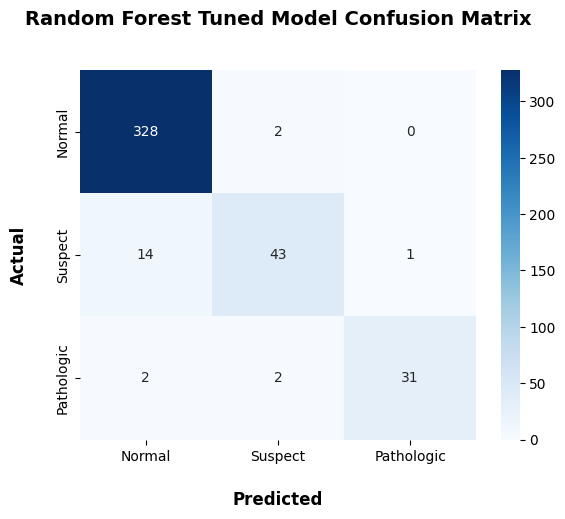

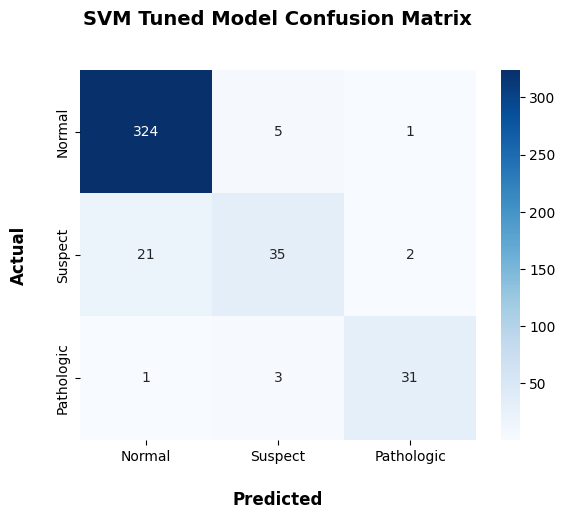

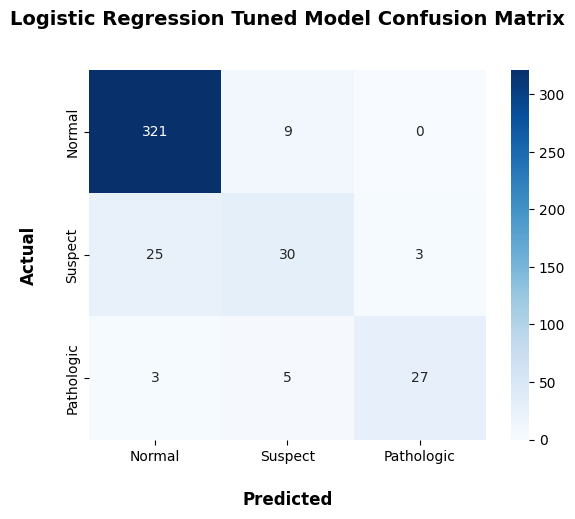

In [147]:
# Get best models
rf_best_model  = rf_grid.best_estimator_
svm_best_model = svm_grid.best_estimator_
lr_best_model  = lr_grid.best_estimator_

# Predictions on test set
best_rf_y_pred  = rf_best_model.predict(X_test)
best_svm_y_pred = svm_best_model.predict(X_test_scaled)
best_lr_y_pred  = lr_best_model.predict(X_test_scaled)

# Evaluate tuned models
for name, pred in zip(
    ['Random Forest', 'SVM', 'Logistic Regression'],
    [best_rf_y_pred, best_svm_y_pred, best_lr_y_pred]):
    print(f"\n{'='*50}")
    print(f"  {name} (Tuned)")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=target_names))


for name,pred in zip(['Random Forest','SVM','Logistic Regression'],
                     [best_rf_y_pred,best_svm_y_pred,best_lr_y_pred]):
  sns.heatmap(confusion_matrix(y_test, pred),
              annot=True, fmt="d",
              xticklabels=target_names,
              yticklabels=target_names,
              cmap='Blues')
  
  plt.xlabel("Predicted",fontweight='bold',
             labelpad=20,fontsize=12)
  plt.ylabel("Actual",fontweight='bold',
             labelpad=20,fontsize=12)
  plt.title(f"{name} Tuned Model Confusion Matrix",
            y=1.1,fontweight='bold',fontsize=14)
  plt.show()

**Testing Our Tunned Models With Our 3 Instances**

In [148]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_best_model.predict(normal_instance)[0]]}")
print(f"SVM:                 {label_map[svm_best_model.predict(normal_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_best_model.predict(normal_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Normal


In [149]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_best_model.predict(suspect_instance)[0]]}")
print(f"SVM:                 {label_map[svm_best_model.predict(suspect_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_best_model.predict(suspect_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Pathologic


In [150]:
print("=== Hypothetical Patient Prediction ===")
print(f"Random Forest:       {label_map[rf_best_model.predict(pathologic_instance)[0]]}")
print(f"SVM:                 {label_map[svm_best_model.predict(pathologic_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[lr_best_model.predict(pathologic_instance_scaled)[0]]}")

=== Hypothetical Patient Prediction ===
Random Forest:       Pathologic
SVM:                 Pathologic
Logistic Regression: Pathologic


All 3 models correctly classified Normal and Pathologic hypothetical patients. However, the Suspect patient was misclassified by all models — Random Forest and SVM predicted Normal while Logistic Regression predicted Pathologic. This highlights the difficulty of detecting Suspect cases due to class imbalance (only 292 Suspect cases vs 1646 Normal) and the overlapping feature values between classes. This further justifies the need for imbalance handling techniques such as SMOTE in future work.

**3.7 Model Serialization**



**Once the model has been trained and optimized, serialize it using a standard format (e.g., Pickle or Joblib). This step allows the model to be saved to a file, making it available for later use without the need for retraining. Name the file algo_best_model.pkl such as linreg_best_model.pkl. Now load the saved model into memory and make predictions, ensuring that the same version of the model is used consistently.**

**Saving My 3 Models**

In [151]:
# Save tuned models following algo_best_model.pkl naming convention
joblib.dump(rf_best_model,'rf_best_model.pkl')
joblib.dump(svm_best_model,'svm_best_model.pkl')
joblib.dump(lr_best_model, 'lr_best_model.pkl')

print("== Models saved successfully! ==")
print("   * rf_best_model.pkl")
print("   * svm_best_model.pkl")
print("   * lr_best_model.pkl")

== Models saved successfully! ==
   * rf_best_model.pkl
   * svm_best_model.pkl
   * lr_best_model.pkl


**Loadind My 3 Models**

In [152]:
# Load models back into memory
loaded_rf  = joblib.load('rf_best_model.pkl')
loaded_svm = joblib.load('svm_best_model.pkl')
loaded_lr  = joblib.load('lr_best_model.pkl')

print("Models loaded successfully!")

Models loaded successfully!


**Running Our 3 Instances**

In [153]:
# Normal instance
print("="*50)
print("  Normal Patient (Loaded Models)")
print("="*50)
print(f"Random Forest:       {label_map[loaded_rf.predict(normal_instance)[0]]}")
print(f"SVM:                 {label_map[loaded_svm.predict(normal_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[loaded_lr.predict(normal_instance_scaled)[0]]}")

# Suspect instance
print("\n"+"="*50)
print("  Suspect Patient (Loaded Models)")
print("="*50)
print(f"Random Forest:       {label_map[loaded_rf.predict(suspect_instance)[0]]}")
print(f"SVM:                 {label_map[loaded_svm.predict(suspect_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[loaded_lr.predict(suspect_instance_scaled)[0]]}")

# Pathologic instance
print("\n"+"="*50)
print("  Pathologic Patient (Loaded Models)")
print("="*50)
print(f"Random Forest:       {label_map[loaded_rf.predict(pathologic_instance)[0]]}")
print(f"SVM:                 {label_map[loaded_svm.predict(pathologic_instance_scaled)[0]]}")
print(f"Logistic Regression: {label_map[loaded_lr.predict(pathologic_instance_scaled)[0]]}")

  Normal Patient (Loaded Models)
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Normal

  Suspect Patient (Loaded Models)
Random Forest:       Normal
SVM:                 Normal
Logistic Regression: Pathologic

  Pathologic Patient (Loaded Models)
Random Forest:       Pathologic
SVM:                 Pathologic
Logistic Regression: Pathologic


As can be seen I've successfullyy saved and loaded our models.